In [36]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from segment_anything import sam_model_registry
import os
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import random

# Проверка устройства и версии PyTorch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch version: {torch.__version__}')
print(f'Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    torch.backends.cudnn.benchmark = True

PyTorch version: 2.7.1+cu118
Using device: cuda
GPU: NVIDIA GeForce RTX 3060


In [ ]:
DATA_DIR = 'dataset'            # папка с train/val/test
SAM_CHECKPOINT = 'sam_vit_b_01ec64.pth'  # путь к скачанному чекпоинту
MODEL_TYPE = 'vit_b'
IMAGE_SIZE = 1024
BATCH_SIZE = 2                          
LEARNING_RATE = 1e-4
NUM_EPOCHS = 100                         
NUM_WORKERS = 0                         

# Имена и количество классов
CLASS_NAMES = ['Фон', 'Пол', 'Стена', 'Мусор']
NUM_CLASSES = len(CLASS_NAMES)
IGNORE_INDEX = 0

# Параметры для разморозки энкодера
UNFREEZE_EPOCH = 40
UNFREEZE_BLOCKS_START = 24

In [38]:
class SegmentationDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.img_dir = os.path.join(root_dir, split, 'images')
        self.mask_dir = os.path.join(root_dir, split, 'masks')
        self.images = sorted(os.listdir(self.img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace('.jpg', '.png'))

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path), dtype=np.int64)  # значения 0..3
        mask = np.clip(mask, 0, NUM_CLASSES - 1)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.long()

In [39]:
# Трансформации
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Создаём датасеты
train_dataset = SegmentationDataset(DATA_DIR, 'train', train_transform)
val_dataset   = SegmentationDataset(DATA_DIR, 'val', val_transform)

# DataLoader-ы
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

print(f'Тренировочных изображений: {len(train_dataset)}')
print(f'Валидационных изображений: {len(val_dataset)}')

Тренировочных изображений: 168
Валидационных изображений: 21


In [40]:
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.3, rotate_limit=45, p=0.8),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
    A.RandomGamma(p=0.3),
    A.GaussianBlur(blur_limit=(3, 9), p=0.3),
    A.CoarseDropout(max_holes=8, max_height=64, max_width=64, fill_value=0, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

C:\Users\DragonSlayer\AppData\Local\Temp\ipykernel_12868\207509160.py:10: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, fill_value=0, p=0.5),


In [ ]:
train_dataset = SegmentationDataset(DATA_DIR, 'train', train_transform)
val_dataset   = SegmentationDataset(DATA_DIR, 'val', val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

pixel_counts = {i: 0 for i in range(NUM_CLASSES)}
total_pixels = 0
for fname in os.listdir(os.path.join(DATA_DIR, 'train', 'masks')):
    mask = np.array(Image.open(os.path.join(DATA_DIR, 'train', 'masks', fname)))
    for i in range(NUM_CLASSES):
        pixel_counts[i] += (mask == i).sum()
    total_pixels += mask.size

print("Распределение классов (train):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {pixel_counts[i]/total_pixels*100:.2f}%")

freqs = [pixel_counts[i] / total_pixels for i in range(NUM_CLASSES)]
weights = [1.0 / (NUM_CLASSES * f) for f in freqs]

class_weights = torch.tensor(weights).float().to(DEVICE)
print("Веса классов:", class_weights)

Распределение классов (train):
  Фон: 67.48%
  Пол: 6.28%
  Стена: 18.16%
  Мусор: 8.07%
Веса классов: tensor([0.3705, 3.9809, 1.3764, 3.0968], device='cuda:0')


In [42]:
class SAMSemanticMulticlass(nn.Module):
    def __init__(self, sam_model, num_classes=4):
        super().__init__()
        self.image_encoder = sam_model.image_encoder
        for param in self.image_encoder.parameters():
            param.requires_grad = False

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, num_classes, kernel_size=1)
        )

    def forward(self, x):
        features = self.image_encoder(x)          # (B, 256, 64, 64)
        logits = self.decoder(features)           # (B, num_classes, 512, 512)
        logits = torch.nn.functional.interpolate(logits, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)
        return logits

In [ ]:
sam = sam_model_registry[MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
model = SAMSemanticMulticlass(sam, num_classes=NUM_CLASSES).to(DEVICE)

# Игнорируем фон
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
scaler = GradScaler()
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print('Модель готова, число обучаемых параметров:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Модель готова, число обучаемых параметров: 185108


C:\Users\DragonSlayer\AppData\Local\Temp\ipykernel_12868\2649412828.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
def compute_metrics(model, dataloader, device, num_classes, ignore_index=0):
    model.eval()
    total_cm = np.zeros((num_classes, num_classes), dtype=np.float64)
    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Исключаем класс фон
            keep_mask = (masks != ignore_index)
            masks_filtered = masks[keep_mask]
            preds_filtered = preds[keep_mask]

            cm = confusion_matrix(masks_filtered.cpu().numpy(), preds_filtered.cpu().numpy(),
                                  labels=list(range(num_classes)))
            total_cm += cm

    iou_per_class = []
    dice_per_class = []
    for cls in range(num_classes):
        tp = total_cm[cls, cls]
        fp = total_cm[:, cls].sum() - tp
        fn = total_cm[cls, :].sum() - tp

        iou_denom = tp + fp + fn
        iou = tp / iou_denom if iou_denom > 0 else float('nan')
        iou_per_class.append(iou)

        dice_denom = 2*tp + fp + fn
        dice = 2*tp / dice_denom if dice_denom > 0 else float('nan')
        dice_per_class.append(dice)

    valid_ious = [iou for iou in iou_per_class if not np.isnan(iou)]
    miou = np.mean(valid_ious) if valid_ious else 0.0
    pixel_acc = np.trace(total_cm) / total_cm.sum() if total_cm.sum() > 0 else 0.0

    return {
        'iou': iou_per_class,
        'dice': dice_per_class,
        'miou': miou,
        'pixel_accuracy': pixel_acc,
        'confusion_matrix': total_cm
    }

def print_metrics(metrics, class_names):
    print("="*50)
    print(f"Pixel Accuracy (без фона): {metrics['pixel_accuracy']:.4f}")
    print(f"Mean IoU (без фона): {metrics['miou']:.4f}")
    print("-"*50)
    for i, name in enumerate(class_names):
        iou = metrics['iou'][i]
        dice = metrics['dice'][i]
        iou_str = f"{iou:.4f}" if not np.isnan(iou) else "N/A"
        dice_str = f"{dice:.4f}" if not np.isnan(dice) else "N/A"
        print(f"{name:15s} | IoU: {iou_str} | Dice: {dice_str}")
    print("="*50)

def visualize_predictions(model, dataloader, device, num_classes,
                         class_colors=None, max_images=3, ignore_index=0):
    if class_colors is None:
        class_colors = np.array([
            [0, 0, 0],       # фон
            [255, 0, 0],     # пол
            [0, 255, 0],     # стена
            [0, 0, 255]      # мусор
        ], dtype=np.uint8)

    model.eval()
    images_shown = 0
    with torch.no_grad():
        for images, masks in dataloader:
            if images_shown >= max_images:
                break
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            masks = masks.cpu().numpy().astype(np.uint8)

            mean = np.array([0.485, 0.456, 0.406])
            std  = np.array([0.229, 0.224, 0.225])
            imgs_np = images.cpu().numpy().transpose(0, 2, 3, 1) * std + mean
            imgs_np = np.clip(imgs_np, 0, 1)

            for i in range(len(images)):
                if images_shown >= max_images:
                    break
                fig, axes = plt.subplots(1, 3, figsize=(15, 5))
                axes[0].imshow(imgs_np[i])
                axes[0].set_title('Изображение')
                axes[0].axis('off')

                gt_colored = class_colors[masks[i]]
                axes[1].imshow(gt_colored)
                axes[1].set_title('Истинная маска')
                axes[1].axis('off')

                pred_colored = class_colors[preds[i]]
                axes[2].imshow(pred_colored)
                axes[2].set_title('Предсказание')
                axes[2].axis('off')

                plt.tight_layout()
                plt.show()
                images_shown += 1

In [ ]:
best_val_miou = 0.0
history = {'train_loss': [], 'val_miou': []}
unfrozen = False

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    loop = tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}')
    for imgs, masks in loop:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    scheduler.step()

    # Валидация
    metrics = compute_metrics(model, val_loader, DEVICE, NUM_CLASSES, ignore_index=IGNORE_INDEX)
    val_miou = metrics['miou']
    history['val_miou'].append(val_miou)

    print(f'\n--- Эпоха {epoch} ---')
    print(f'Train Loss: {avg_train_loss:.4f}')
    print_metrics(metrics, CLASS_NAMES)

    # Сохраняем лучшую модель
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'Сохранена лучшая модель (mIoU = {val_miou:.4f})')

    # Разморозка энкодера
    if not unfrozen and epoch == UNFREEZE_EPOCH:
        print('\nРазмораживаем последние блоки энкодера SAM...')
        for name, param in model.image_encoder.named_parameters():
            if 'blocks.' in name:
                block_num = int(name.split('.')[1])
                if block_num >= UNFREEZE_BLOCKS_START:
                    param.requires_grad = True

        optimizer = AdamW([
            {'params': model.decoder.parameters(), 'lr': 1e-4},
            {'params': filter(lambda p: p.requires_grad, model.image_encoder.parameters()), 'lr': 1e-5}
        ])

        scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - epoch, eta_min=1e-6)
        unfrozen = True
        print('Оптимизатор и планировщик обновлены')

print('Обучение завершено')

Epoch 1/100:   0%|          | 0/84 [00:00<?, ?it/s]

C:\Users\DragonSlayer\AppData\Local\Temp\ipykernel_12868\4047695451.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



--- Эпоха 1 ---
Train Loss: 1.2940
Pixel Accuracy (без фона): 0.7168
Mean IoU (без фона): 0.3746
--------------------------------------------------
Фон             | IoU: 0.0000 | Dice: 0.0000
Пол             | IoU: 0.5528 | Dice: 0.7120
Стена           | IoU: 0.6504 | Dice: 0.7882
Мусор           | IoU: 0.2950 | Dice: 0.4556
✅ Сохранена лучшая модель (mIoU = 0.3746)


Epoch 2/100:   0%|          | 0/84 [00:00<?, ?it/s]

C:\Users\DragonSlayer\AppData\Local\Temp\ipykernel_12868\4047695451.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

C:\Users\DragonSlayer\AppData\Local\Temp\ipykernel_12868\4047695451.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



--- Эпоха 13 ---
Train Loss: 0.5705
Pixel Accuracy (без фона): 0.9045
Mean IoU (без фона): 0.7760
--------------------------------------------------
Фон             | IoU: N/A | Dice: N/A
Пол             | IoU: 0.7853 | Dice: 0.8797
Стена           | IoU: 0.8766 | Dice: 0.9342
Мусор           | IoU: 0.6661 | Dice: 0.7996
✅ Сохранена лучшая модель (mIoU = 0.7760)


Epoch 14/100:   0%|          | 0/84 [00:00<?, ?it/s]

C:\Users\DragonSlayer\AppData\Local\Temp\ipykernel_12868\4047695451.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


KeyboardInterrupt: 

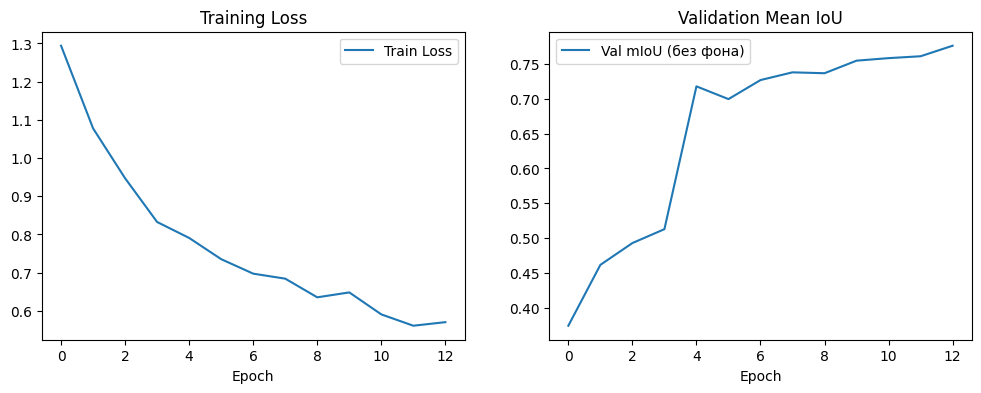

In [46]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_miou'], label='Val mIoU (без фона)')
plt.title('Validation Mean IoU')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [47]:
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model.eval()

print('Финальные метрики на валидации:')
final_metrics = compute_metrics(model, val_loader, DEVICE, NUM_CLASSES, ignore_index=IGNORE_INDEX)
print_metrics(final_metrics, CLASS_NAMES)

Финальные метрики на валидации:
Pixel Accuracy (без фона): 0.9045
Mean IoU (без фона): 0.7760
--------------------------------------------------
Фон             | IoU: N/A | Dice: N/A
Пол             | IoU: 0.7853 | Dice: 0.8797
Стена           | IoU: 0.8766 | Dice: 0.9342
Мусор           | IoU: 0.6661 | Dice: 0.7996


In [53]:
def show_single_prediction(idx):
    img_tensor, mask_tensor = val_dataset[idx]  # (C,H,W), (H,W)
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)  # батч из 1
    
    with torch.no_grad():
        logits = model(img_tensor)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    mask = mask_tensor.cpu().numpy().astype(np.uint8)
    
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_np = img_tensor.squeeze(0).cpu().numpy().transpose(1,2,0) * std + mean
    img_np = np.clip(img_np, 0, 1)
    
    # маски
    gt_colored = class_colors[mask]
    pred_colored = class_colors[pred]
    
    # отрисовка
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title('Изображение')
    axes[0].axis('off')
    axes[1].imshow(gt_colored)
    axes[1].set_title('Истинная маска')
    axes[1].axis('off')
    axes[2].imshow(pred_colored)
    axes[2].set_title('Предсказание')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

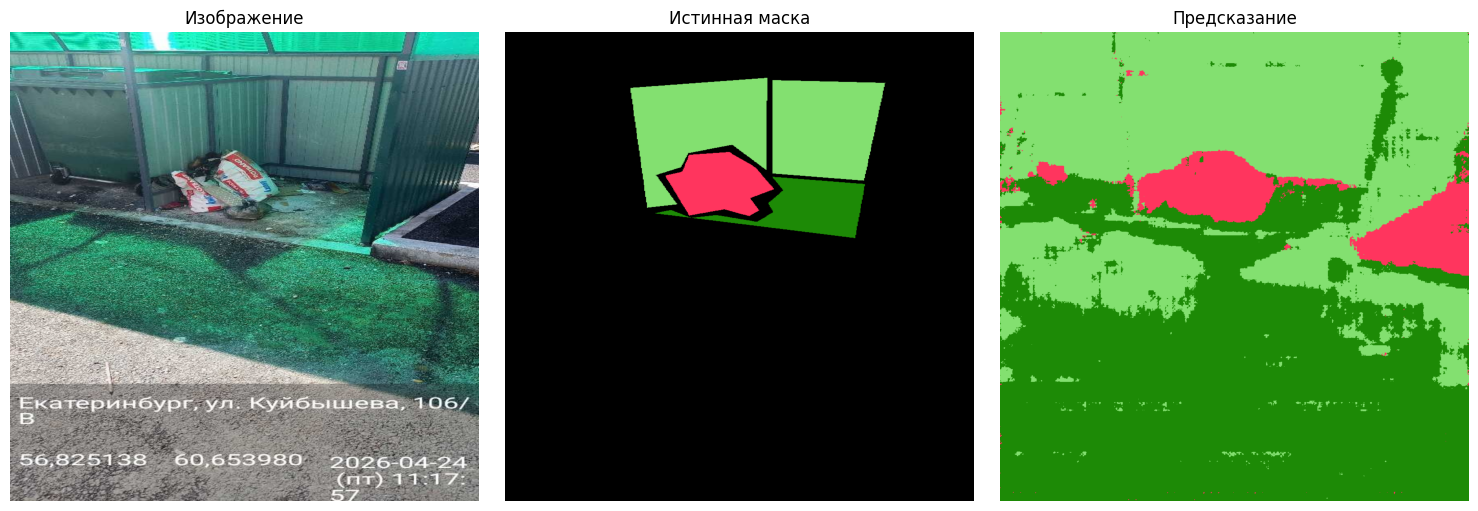

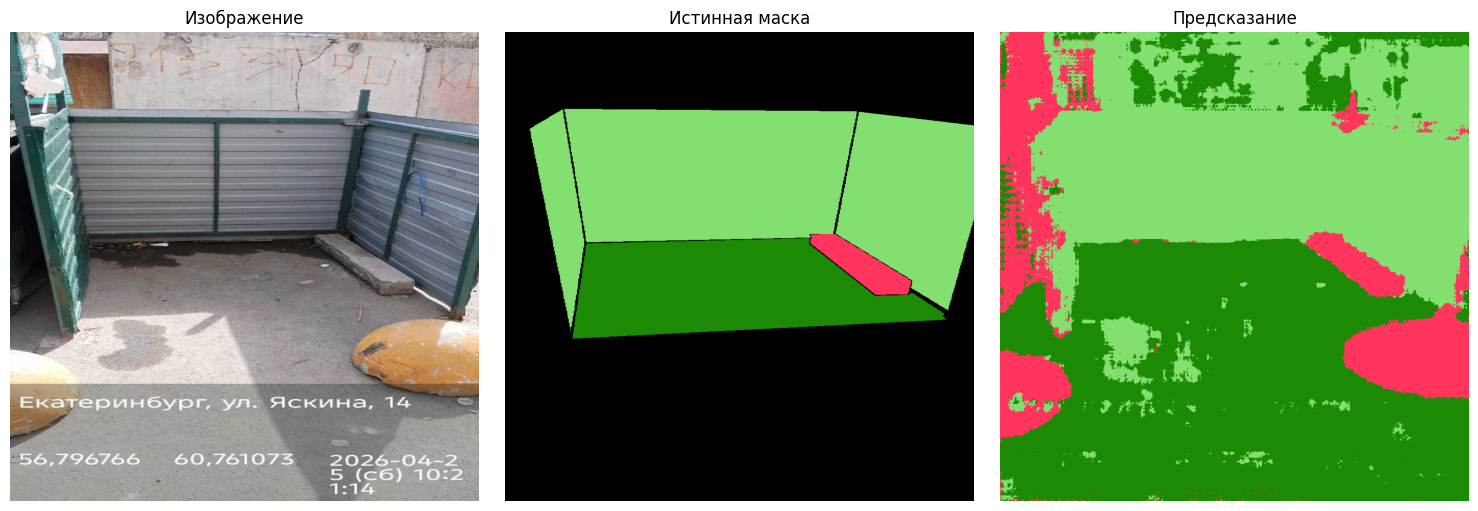

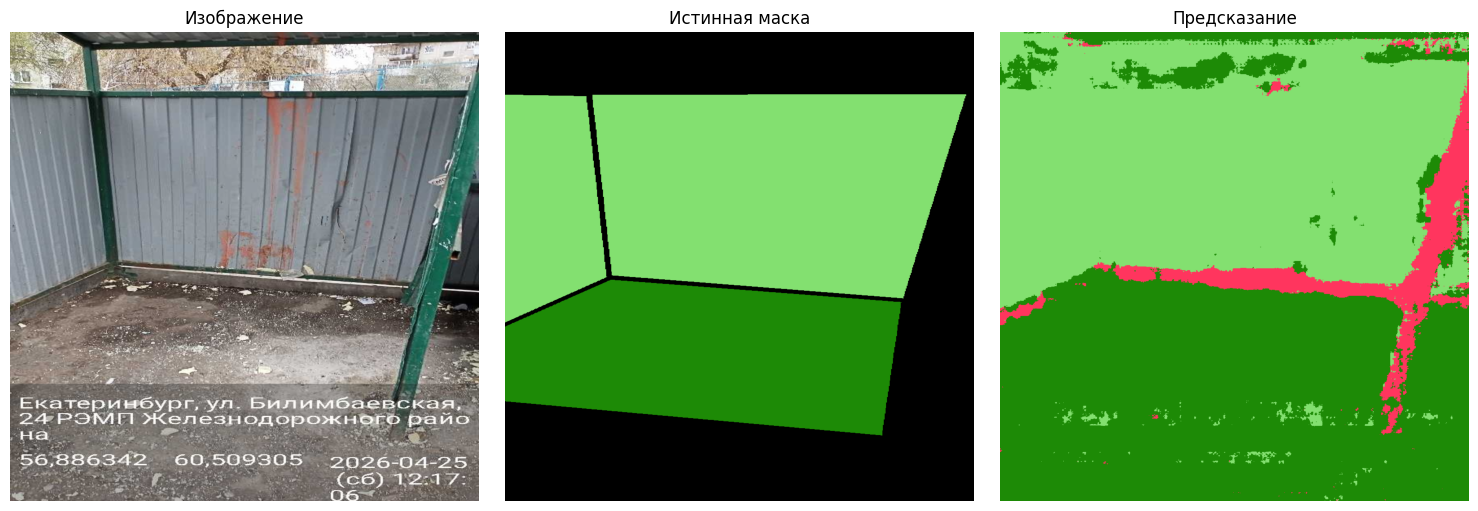

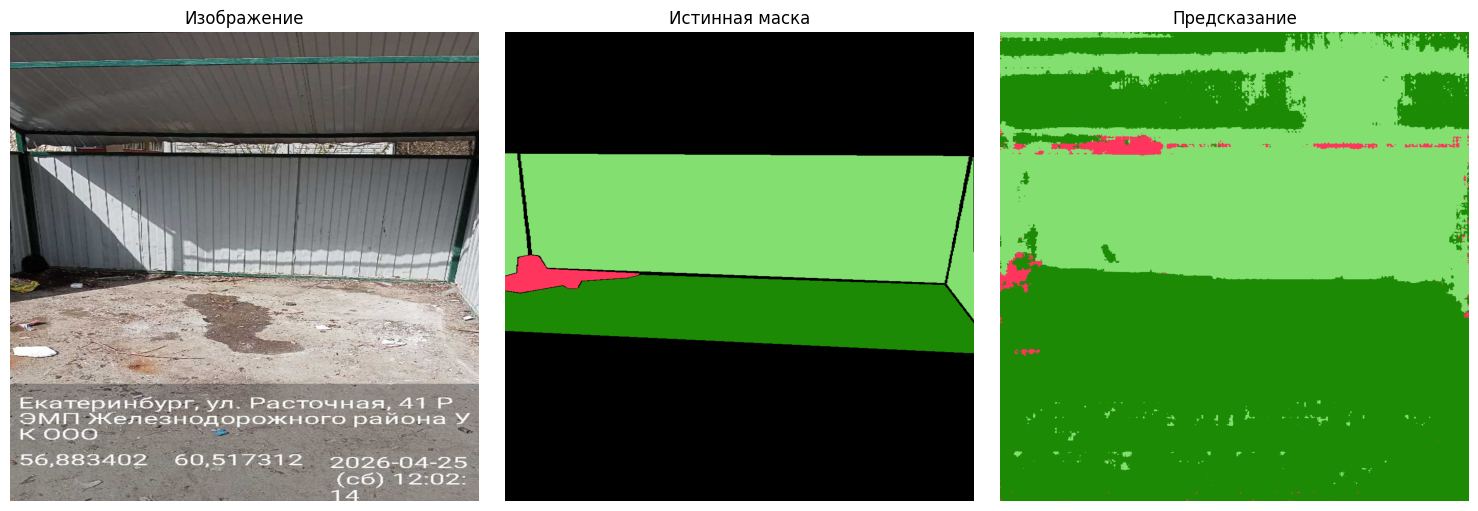

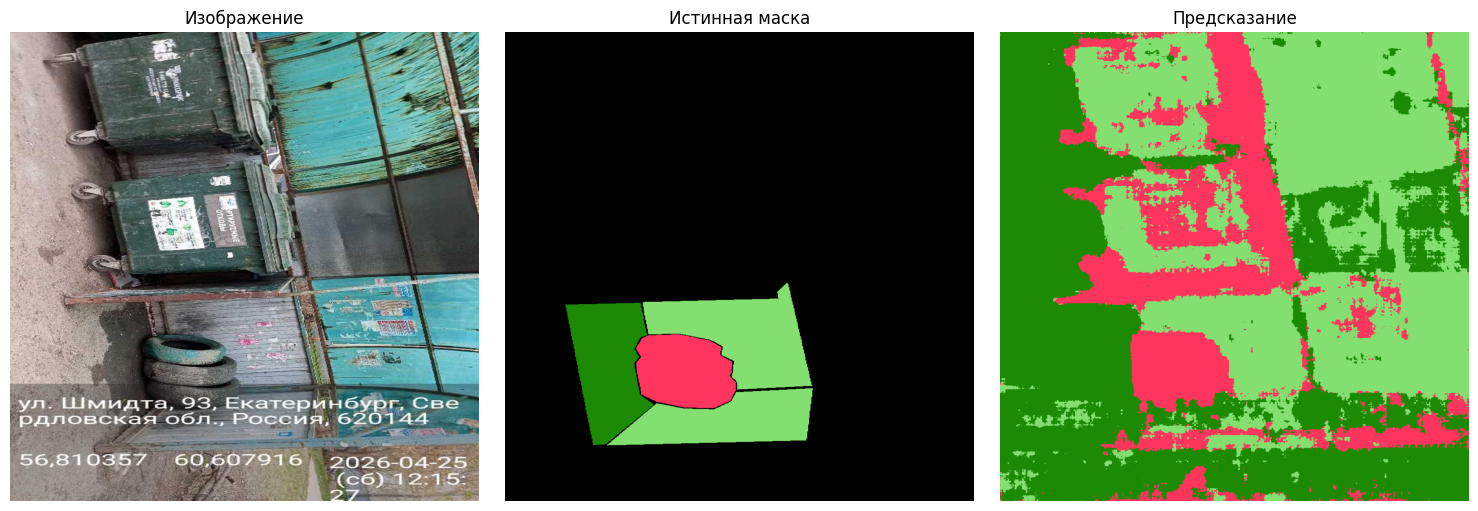

In [61]:
import random

indices = list(range(len(val_dataset)))
random.shuffle(indices)
selected_indices = indices[:5]

# Цвета для визуализации: фон, пол, стена, мусор
class_colors = np.array([[0, 0, 0], [29, 138, 6], [131, 224, 112], [255, 53, 94]], dtype=np.uint8)

for idx in selected_indices:
    show_single_prediction(idx) 